In [10]:
%pip install torch torchvision pillow

Note: you may need to restart the kernel to use updated packages.


In [11]:
import torch

In [12]:
from PIL import Image
import torchvision.transforms as transforms

img = Image.open("D:\Conv\Screenshot (2).png").convert('RGB')

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

img_tensor = transform(img)
print(img_tensor)

tensor([[[0.1137, 0.1373, 0.1529,  ..., 0.2392, 0.2078, 0.2000],
         [0.3686, 0.4980, 0.5608,  ..., 0.6392, 0.6078, 0.5804],
         [0.5294, 0.6471, 0.6706,  ..., 0.6863, 0.6667, 0.6471],
         ...,
         [0.1490, 0.5490, 0.6510,  ..., 0.6196, 0.6706, 0.6471],
         [0.1373, 0.5255, 0.6353,  ..., 0.6588, 0.6549, 0.6314],
         [0.1255, 0.4980, 0.6235,  ..., 0.6510, 0.6353, 0.6078]],

        [[0.1765, 0.2039, 0.2196,  ..., 0.3137, 0.2863, 0.2784],
         [0.4235, 0.5608, 0.6275,  ..., 0.7098, 0.6784, 0.6510],
         [0.5843, 0.7176, 0.7451,  ..., 0.7569, 0.7412, 0.7176],
         ...,
         [0.1490, 0.5922, 0.7059,  ..., 0.6745, 0.7294, 0.7137],
         [0.1373, 0.5686, 0.6941,  ..., 0.7176, 0.7137, 0.6941],
         [0.1255, 0.5412, 0.6824,  ..., 0.7098, 0.6980, 0.6706]],

        [[0.2902, 0.3294, 0.3647,  ..., 0.4784, 0.4392, 0.4275],
         [0.6157, 0.7490, 0.8157,  ..., 0.8941, 0.8627, 0.8353],
         [0.7922, 0.9059, 0.9294,  ..., 0.9412, 0.9216, 0.

<>:4: SyntaxWarning: invalid escape sequence '\C'
<>:4: SyntaxWarning: invalid escape sequence '\C'
C:\Users\leohi\AppData\Local\Temp\ipykernel_26664\2312495762.py:4: SyntaxWarning: invalid escape sequence '\C'
  img = Image.open("D:\Conv\Screenshot (2).png").convert('RGB')


In [13]:
img_tensor = img_tensor.unsqueeze(0)
print(img_tensor.shape)

torch.Size([1, 3, 224, 224])


In [14]:
k = 19
center = k//2

import numpy as np 
sigma =8
kernel = np.zeros((k,k))

for i in range(k):
    for j in range(k) :
        x =i -center
        y =j -center

        kernel[i,j] = np.exp(-(x**2 +y**2)/(2*sigma**2))
kernel = kernel /(np.sum(kernel))
kernel_torch = torch.from_numpy(kernel).float()


In [15]:
import torch.nn.functional as F
blur_weight = kernel_torch.expand(3,1,19,19).contiguous()
output = F.conv2d(img_tensor, blur_weight, padding =8, groups =3)

In [16]:
print("Image Shape: ", output)

Image Shape:  tensor([[[[0.2332, 0.2609, 0.2881,  ..., 0.2931, 0.2665, 0.2392],
          [0.2618, 0.2926, 0.3230,  ..., 0.3274, 0.2977, 0.2674],
          [0.2897, 0.3237, 0.3571,  ..., 0.3608, 0.3282, 0.2949],
          ...,
          [0.2629, 0.2964, 0.3286,  ..., 0.2361, 0.2252, 0.2123],
          [0.2388, 0.2693, 0.2987,  ..., 0.2188, 0.2081, 0.1958],
          [0.2145, 0.2420, 0.2684,  ..., 0.2005, 0.1902, 0.1785]],

         [[0.2591, 0.2892, 0.3187,  ..., 0.3261, 0.2968, 0.2667],
          [0.2902, 0.3237, 0.3566,  ..., 0.3640, 0.3314, 0.2979],
          [0.3207, 0.3575, 0.3936,  ..., 0.4009, 0.3651, 0.3283],
          ...,
          [0.2794, 0.3151, 0.3495,  ..., 0.2431, 0.2317, 0.2186],
          [0.2550, 0.2876, 0.3190,  ..., 0.2248, 0.2137, 0.2011],
          [0.2298, 0.2593, 0.2876,  ..., 0.2056, 0.1949, 0.1829]],

         [[0.3180, 0.3533, 0.3876,  ..., 0.3978, 0.3631, 0.3272],
          [0.3550, 0.3942, 0.4323,  ..., 0.4429, 0.4043, 0.3645],
          [0.3911, 0.4342, 0

In [17]:
print("Red Sum:", img_tensor[0, 0, 0:3, 0:3].sum() * 0.04)


Red Sum: tensor(0.1471)


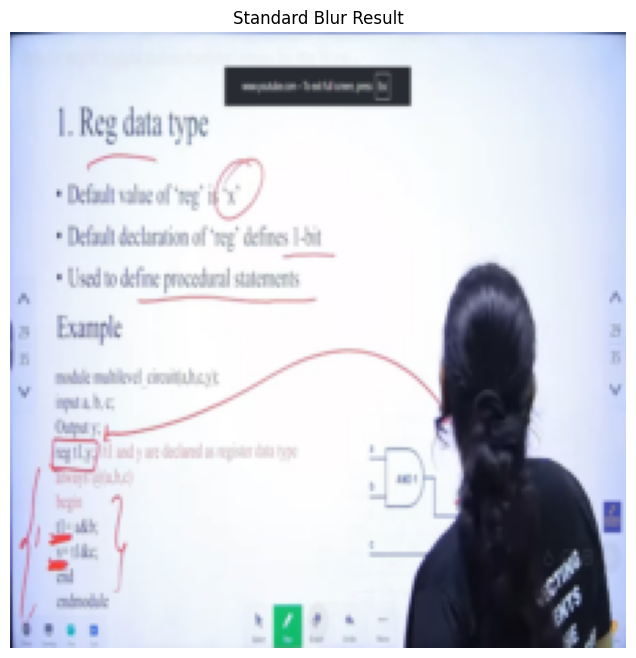

In [18]:
import matplotlib.pyplot as plt
output_tensor = img_tensor.squeeze(0)
output_img = output_tensor.permute(1,2,0)
final_display = output_img.detach().cpu().numpy()

# Step D: Clip the values
# Sometimes math goes slightly over 1.0 or under 0.0; clipping keeps it clean
import numpy as np
final_display = np.clip(final_display, 0, 1)

# Step E: Plot
plt.figure(figsize=(8, 8))
plt.imshow(final_display)
plt.axis('off') # Hide the X and Y numbers
plt.title("Standard Blur Result")
plt.show()